# TWEET SENTIMENT ANALYSIS

### Aim and info about the dataset

#### *This is an entity-level sentiment analysis dataset of twitter. Given a message and an entity, the task is to judge the sentiment of the message about the entity. There are three classes in this dataset: Positive, Negative and Neutral. We regard messages that are not relevant to the entity (i.e. Irrelevant) as Neutral.*

In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Importing the dataset
df_train = pd.read_csv('twitter_training.csv')
df_valid = pd.read_csv('twitter_validation.csv')

In [3]:
df_train.shape

(74681, 4)

In [4]:
df_valid.shape

(999, 4)

In [5]:
df_train.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


### Basic Text Preprocessing

In [6]:
# Assigning the column names

df_train.columns = ['tweet_id','feature_2','sentiment','tweet']
df_valid.columns = ['tweet_id','feature_2','sentiment','tweet']

df_train.head()

,tweet_id,feature_2,sentiment,tweet
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [7]:
df_train = df_train.drop(columns = ['tweet_id','feature_2'])
df_valid = df_valid.drop(columns = ['tweet_id','feature_2'])

#### Handling Nulls

In [8]:
df_train['tweet'].isnull().sum()

np.int64(686)

In [9]:
df_valid['tweet'].isnull().sum()

np.int64(0)

In [10]:
df_train.dropna(subset=['tweet'],inplace=True)

#### Handling Duplicates

In [11]:
df_train.duplicated().sum()

np.int64(4227)

In [12]:
df_valid.duplicated().sum()

np.int64(1)

In [13]:
df_train.drop_duplicates(inplace=True)

In [14]:
df_valid.drop_duplicates(inplace=True)

#### Checking Class Distribution

In [15]:
df_train['sentiment'].value_counts()

sentiment
Negative      21237
Positive      19137
Neutral       17110
Irrelevant    12284
Name: count, dtype: int64

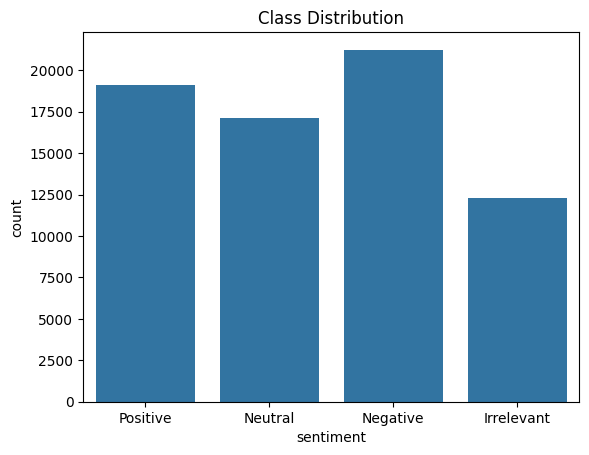

In [16]:
sns.countplot(x='sentiment', data=df_train)
plt.title('Class Distribution')
plt.show()

In [17]:
!pip install regex

In [18]:
# Importing Python’s regular expression (regex) module.
# It lets us search, match, and manipulate strings using patterns.
import re

def clean_tweet(text):
    text = str(text).strip()                    # remove leading/trailing whitespace
    text = re.sub(r'http\S+|www\S+', '', text)  # remove URLs
    text = re.sub(r'@\w+', '', text)            # remove mentions
    text = re.sub(r'#', '', text)               # remove hashtags symbol
    text = re.sub(r'[^a-zA-Z\s]', '', text)     # remove numbers, punctuation, special chars
    text = text.lower()
    return text

In [19]:
# Cleaning the tweets

df_train['clean_tweet'] = df_train['tweet'].apply(clean_tweet)
df_valid['clean_tweet'] = df_valid['tweet'].apply(clean_tweet)

In [20]:
df_train['clean_tweet']

0        i am coming to the borders and i will kill you...
1        im getting on borderlands and i will kill you all
2        im coming on borderlands and i will murder you...
3        im getting on borderlands  and i will murder y...
4        im getting into borderlands and i can murder y...
                               ...                        
74676    just realized that the windows partition of my...
74677    just realized that my mac window partition is ...
74678    just realized the windows partition of my mac ...
74679    just realized between the windows partition of...
74680    just like the windows partition of my mac is l...
Name: clean_tweet, Length: 69768, dtype: object

In [21]:
df_train.drop(columns=['tweet'],inplace=True)
df_valid.drop(columns=['tweet'],inplace=True)

#### Tokenisation



In [22]:
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

df_train['tokens'] = df_train['clean_tweet'].apply(word_tokenize)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\91976\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [23]:
df_valid['tokens'] = df_valid['clean_tweet'].apply(word_tokenize)

In [24]:
df_train['tokens'].head()

0    [i, am, coming, to, the, borders, and, i, will...
1    [im, getting, on, borderlands, and, i, will, k...
2    [im, coming, on, borderlands, and, i, will, mu...
3    [im, getting, on, borderlands, and, i, will, m...
4    [im, getting, into, borderlands, and, i, can, ...
Name: tokens, dtype: object

In [25]:
df_valid['tokens'].head()

0    [bbc, news, amazon, boss, jeff, bezos, rejects...
1    [why, do, i, pay, for, word, when, it, functio...
2    [csgo, matchmaking, is, so, full, of, closet, ...
3    [now, the, president, is, slapping, americans,...
4    [hi, ive, had, madeleine, mccann, in, my, cell...
Name: tokens, dtype: object

#### Lemmatization

In [26]:
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

df_train['lemmas'] = df_train['tokens'].apply(lambda x : [lemmatizer.lemmatize(word) for word in x])


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\91976\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [27]:
df_valid['lemmas'] = df_valid['tokens'].apply(lambda x : [lemmatizer.lemmatize(word) for word in x])

#### Word Embeddings using Word2Vec

In [28]:
from gensim.models import Word2Vec

sentences_train = df_train['lemmas'].tolist()

In [43]:
w2v_model = Word2Vec(sentences_train,vector_size=100,window=3,min_count=2,epochs=10)

In [44]:
w2v_model.wv.index_to_key

['the',
 'i',
 'to',
 'a',
 'and',
 'of',
 'it',
 'is',
 'for',
 'in',
 'this',
 'you',
 'on',
 'my',
 'game',
 'that',
 'with',
 'so',
 'me',
 'just',
 'but',
 'have',
 'be',
 'not',
 'are',
 'all',
 'wa',
 'at',
 'like',
 'im',
 'out',
 'from',
 'get',
 'your',
 'now',
 'we',
 'can',
 'they',
 'one',
 'if',
 'play',
 'ha',
 'good',
 'about',
 'no',
 'will',
 'an',
 'really',
 'love',
 'when',
 'new',
 'up',
 'time',
 'what',
 'more',
 'do',
 'u',
 'by',
 'how',
 'johnson',
 'or',
 'why',
 'see',
 'people',
 'shit',
 'some',
 'cant',
 'dont',
 'been',
 'got',
 'best',
 'still',
 'player',
 'year',
 'day',
 'make',
 'go',
 'who',
 'great',
 'even',
 'playing',
 'because',
 'p',
 'there',
 'look',
 'fucking',
 'rhandlerr',
 'xbox',
 'fuck',
 'please',
 'had',
 'dead',
 'facebook',
 'only',
 'back',
 'he',
 's',
 'google',
 'amazon',
 'know',
 'much',
 'am',
 'their',
 'our',
 'after',
 'guy',
 'going',
 'fifa',
 'red',
 'would',
 'microsoft',
 'over',
 'here',
 'them',
 'ive',
 'want',


In [45]:
df_train['lemmas'].apply(len).describe()

count    69768.000000
mean        18.321050
std         13.295185
min          0.000000
25%          8.000000
50%         15.000000
75%         26.000000
max        166.000000
Name: lemmas, dtype: float64

#### Converting tweets to sequence of vectors

In [84]:
max_len = 65

In [85]:
def tweet_to_sequence(words, model, vector_size, max_len):

    sequence =[]

    for word in words:
        if word in model.wv:
            sequence.append(model.wv[word])
        else:
            sequence.append(np.zeros(vector_size))

    if len(sequence)< max_len:
        padding = [np.zeros(vector_size)]*(max_len-len(sequence))
        sequence.extend(padding)

    else:
        sequence = sequence[:max_len]
        
    return np.array(sequence)

In [86]:
x_train = df_train['lemmas'].apply(lambda x: tweet_to_sequence(x, w2v_model,100,max_len))

In [87]:
x_train = np.stack(x_train) # Converting to 3D tensor

In [88]:
x_train.shape

(69768, 65, 100)

In [89]:
x_valid = df_valid['lemmas'].apply(lambda x: tweet_to_sequence(x, w2v_model,100,max_len))


In [90]:
x_valid = np.stack(x_valid) # Converting to 3D tensor

In [91]:
x_valid.shape

(998, 65, 100)

#### Encoding the Labels

In [92]:
import sklearn
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(df_train['sentiment'])

In [93]:
y_valid = le.transform(df_valid['sentiment'])

In [94]:
import tensorflow
import keras

from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train,num_classes=4)
y_valid = to_categorical(y_valid,num_classes=4)


#### Building the Neural Network

In [95]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional

model_Dl = Sequential([Bidirectional(LSTM(128, return_sequences=True, input_shape = (max_len, 100))),
                       Dropout(0.3),

                       Bidirectional(LSTM(64)),
                       Dropout(0.3),
                       
                       Dense(64, activation='relu'),
                       Dense(4, activation='softmax')])


c:\Users\91976\anaconda3\envs\tweet_dl\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


#### Compiling the Model

In [96]:
model_Dl.compile(optimizer='adam',
                 loss = 'categorical_crossentropy',
                 metrics =['accuracy'])

#### Training the Model

In [97]:
train_model = model_Dl.fit(x_train,
                           y_train,
                           validation_data =(x_valid,y_valid),
                           epochs = 7,
                           batch_size = 128
)

Epoch 1/7
546/546 ━━━━━━━━━━━━━━━━━━━━ 239s 416ms/step - accuracy: 0.5472 - loss: 1.0725 - val_accuracy: 0.6222 - val_loss: 0.9037
Epoch 2/7
546/546 ━━━━━━━━━━━━━━━━━━━━ 199s 364ms/step - accuracy: 0.6240 - loss: 0.9155 - val_accuracy: 0.7174 - val_loss: 0.6964
Epoch 3/7
546/546 ━━━━━━━━━━━━━━━━━━━━ 196s 359ms/step - accuracy: 0.6949 - loss: 0.7630 - val_accuracy: 0.8216 - val_loss: 0.4933
Epoch 4/7
546/546 ━━━━━━━━━━━━━━━━━━━━ 192s 351ms/step - accuracy: 0.7643 - loss: 0.6097 - val_accuracy: 0.8567 - val_loss: 0.4000
Epoch 5/7
546/546 ━━━━━━━━━━━━━━━━━━━━ 193s 353ms/step - accuracy: 0.8143 - loss: 0.4896 - val_accuracy: 0.8998 - val_loss: 0.2930
Epoch 6/7
546/546 ━━━━━━━━━━━━━━━━━━━━ 191s 351ms/step - accuracy: 0.8515 - loss: 0.3944 - val_accuracy: 0.9339 - val_loss: 0.2194
Epoch 7/7
546/546 ━━━━━━━━━━━━━━━━━━━━ 191s 350ms/step - accuracy: 0.8772 - loss: 0.3324 - val_accuracy: 0.9339 - val_loss: 0.1954


#### Accuracy and Classification report

In [102]:
print("Training Accuracy:", train_model.history['accuracy'][-1])
print("Validation Accuracy:", train_model.history['val_accuracy'][-1])

Training Accuracy: 0.8771643042564392
Validation Accuracy: 0.9338677525520325


In [103]:
from sklearn.metrics import classification_report

y_pred = model_Dl.predict(x_valid)
y_pred = y_pred.argmax(axis=1)
y_true = y_valid.argmax(axis=1)

print(classification_report(y_true,y_pred))

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       171
           1       0.96      0.95      0.95       266
           2       0.94      0.91      0.93       285
           3       0.94      0.95      0.94       276

    accuracy                           0.93       998
   macro avg       0.93      0.93      0.93       998
weighted avg       0.93      0.93      0.93       998



#### Plotting training and validation accuracy

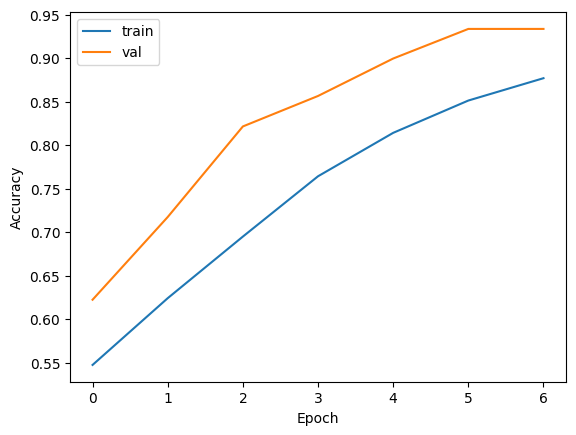

In [99]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.plot(train_model.history['accuracy'], label='train')
plt.plot(train_model.history['val_accuracy'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#### Saving the model

In [104]:
model_Dl.save('tweet_sentiment_analysis_model.h5')

In [113]:
w2v_model.save('w2v_model.model')

## Results

#### The Bidirectional LSTM model was trained on approximately 70K tweets using Word2Vec embeddings.  
 
#### The model was evaluated using a classification report on the test dataset. The model achieved an overall accuracy of 93%, with precision, recall, and F1-scores consistently above 0.90 across all sentiment classes.